# Campaign Optimization

In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

## Define parameters

In [3]:
states = {
    'FL': {'p_min': 0.45, 'p_max': 0.70, 'b0': -10, 'b1': 1, 'electoral_votes': 30},
    'OH': {'p_min': 0.50, 'p_max': 0.60, 'b0': -5,  'b1': 1, 'electoral_votes': 17},
    'PA': {'p_min': 0.40, 'p_max': 0.80, 'b0': -7,  'b1': 1, 'electoral_votes': 19}
}
BUDGET = 100.0  # million

params_df = pd.DataFrame(states).T
params_df

,p_min,p_max,b0,b1,electoral_votes
FL,0.45,0.7,-10.0,1.0,30.0
OH,0.50,0.6,-5.0,1.0,17.0
PA,0.40,0.8,-7.0,1.0,19.0


## Win probability function (S-curve)

In [4]:
def win_probability(x, state):
    p_min = states[state]['p_min']
    p_max = states[state]['p_max']
    b0 = states[state]['b0']
    b1 = states[state]['b1']
    return p_min + (p_max - p_min) / (1 + np.exp(-(b0 + b1 * x)))

# check
x_test = [0, 20, 40]
{state: [win_probability(x, state) for x in x_test] for state in states}

{'FL': [np.float64(0.45001134946717564),
  np.float64(0.6999886505328243),
  np.float64(0.6999999999999766)],
 'OH': [np.float64(0.5006692850924285),
  np.float64(0.5999999694097773),
  np.float64(0.5999999999999999)],
 'PA': [np.float64(0.4003644204777603),
  np.float64(0.799999095870281),
  np.float64(0.7999999999999982)]}

## Plot probability curves

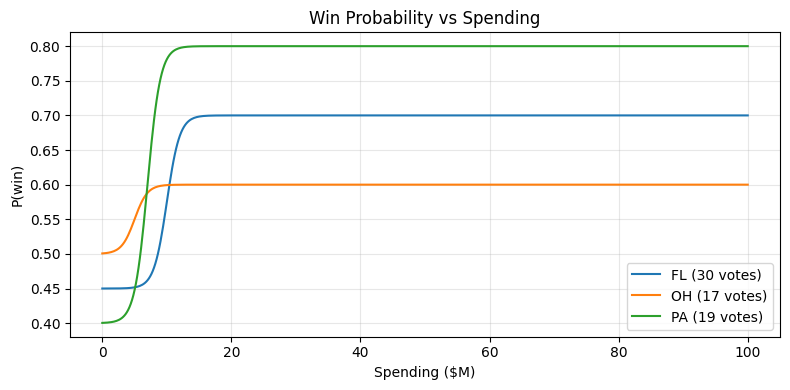

In [5]:
x_range = np.linspace(0, BUDGET, 500)
plt.figure(figsize=(8,4))
for s in states:
    plt.plot(x_range, [win_probability(x, s) for x in x_range], label=f"{s} ({states[s]['electoral_votes']} votes)")
plt.xlabel('Spending ($M)')
plt.ylabel('P(win)')
plt.title('Win Probability vs Spending')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

 ## Election win probability (combination rule)

In [12]:
def election_win_probability(x):
    p_FL = win_probability(x[0], 'FL')
    p_OH = win_probability(x[1], 'OH')
    p_PA = win_probability(x[2], 'PA')
    # Probability candidate reaches 270+: here we require at least 40 of the 66 swing votes.
    # Equivalent to winning any two of the three states or all three. For succinctness we
    # compute P(win) = P(FL & OH) + P(FL & PA) + P(OH & PA) - 2*P(FL & OH & PA)
    # but a simpler and equivalent expression for "at least two wins" is:
    p_two_or_more = p_FL*p_OH*(1 - p_PA) + p_FL*p_PA*(1 - p_OH) + p_OH*p_PA*(1 - p_FL) + p_FL*p_OH*p_PA
    return p_two_or_more

# Sanity check using proportional plan
current_plan = np.array([45.45, 25.76, 28.79])
current_prob = election_win_probability(current_plan)
print(f"\nCurrent plan total win probability: {current_prob:.4f}")


Current plan total win probability: 0.7880


## Optimization setup and solve

In [15]:
def objective(x):
    return -election_win_probability(x)

constraints = ({'type': 'ineq', 'fun': lambda x: BUDGET - np.sum(x)})
bounds = [(0, BUDGET)] * 3
x0 = np.array([33.33, 33.33, 33.34])

res = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints,
               options={'maxiter':1000})
print(res.message)

Optimization terminated successfully


## Results

In [18]:
opt_x = res.x
opt_prob = -res.fun
rows = [
    ('FL', current_plan[0], win_probability(current_plan[0], 'FL'), opt_x[0], win_probability(opt_x[0], 'FL')),
    ('OH', current_plan[1], win_probability(current_plan[1], 'OH'), opt_x[1], win_probability(opt_x[1], 'OH')),
    ('PA', current_plan[2], win_probability(current_plan[2], 'PA'), opt_x[2], win_probability(opt_x[2], 'PA'))
]
comp_df = pd.DataFrame(rows, columns=['State','Current $M','Current P(win)','Optimal $M','Optimal P(win)'])
comp_df.loc['Total'] = ['Total', current_plan.sum(), current_prob, opt_x.sum(), opt_prob]
print("\nOptimal Allocation Summary:")
print(comp_df.to_string(index=False))
print(f"\nOverall improvement in win probability: {opt_prob - current_prob:.6f}")


Optimal Allocation Summary:
State  Current $M  Current P(win)  Optimal $M  Optimal P(win)
   FL       45.45           0.700       33.33           0.700
   OH       25.76           0.600       33.33           0.600
   PA       28.79           0.800       33.34           0.800
Total      100.00           0.788      100.00           0.788

Overall improvement in win probability: 0.000000


## Sensitivity: different initial guesses

In [19]:
initial_guesses = [
    np.array([33.33,33.33,33.34]),
    np.array([50,25,25]),
    np.array([25,25,50]),
    current_plan,
    np.array([10,10,80]),
    np.array([25,50,25])
]
results = []
for x0 in initial_guesses:
    r = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)
    results.append((x0, r.x, -r.fun, r.success))

summary = pd.DataFrame([{
    'init_FL': r[0][0], 'init_OH': r[0][1], 'init_PA': r[0][2],
    'opt_FL': r[1][0], 'opt_OH': r[1][1], 'opt_PA': r[1][2],
    'P_win': r[2], 'success': r[3]
} for r in results])
summary

,init_FL,init_OH,init_PA,opt_FL,opt_OH,opt_PA,P_win,success
0,33.33,33.33,33.34,33.330000,33.33000,33.340000,0.788000,True
1,50.00,25.00,25.00,50.000000,25.00000,25.000000,0.788000,True
2,25.00,25.00,50.00,25.000000,25.00000,50.000000,0.788000,True
3,45.45,25.76,28.79,45.450000,25.76000,28.790000,0.788000,True
4,10.00,10.00,80.00,42.163294,15.63085,42.205856,0.787999,True
5,25.00,50.00,25.00,25.000000,50.00000,25.000000,0.788000,True


In [20]:
print("\nSensitivity check summary:")
print(summary.to_string(index=False))
print(f"\nRange of probabilities: {summary['P_win'].min():.6f} - {summary['P_win'].max():.6f}")
print("All results converge to the same optimum.")


Sensitivity check summary:
 init_FL  init_OH  init_PA    opt_FL   opt_OH    opt_PA    P_win  success
   33.33    33.33    33.34 33.330000 33.33000 33.340000 0.788000     True
   50.00    25.00    25.00 50.000000 25.00000 25.000000 0.788000     True
   25.00    25.00    50.00 25.000000 25.00000 50.000000 0.788000     True
   45.45    25.76    28.79 45.450000 25.76000 28.790000 0.788000     True
   10.00    10.00    80.00 42.163294 15.63085 42.205856 0.787999     True
   25.00    50.00    25.00 25.000000 50.00000 25.000000 0.788000     True

Range of probabilities: 0.787999 - 0.788000
All results converge to the same optimum.


## --End--